# Transformer Mechanics from Scratch: An Educational Tutorial with Interactive Attention Visualizations and Weight Interpretability

Welcome to this comprehensive, educational tutorial on **Transformers**! 

Since their introduction in the seminal paper *"Attention Is All You Need"* (Vaswani et al., 2017), Transformer architectures have revolutionized deep learning across natural language processing, computer vision, audio, and scientific modeling. Unlike classical recurrent neural networks (RNNs) that process data sequentially, or convolutional networks (CNNs) that operate within local receptive fields, Transformers rely entirely on the **Self-Attention mechanism**. This allows them to compute global dependencies between any two tokens in a sequence in parallel, making them highly efficient and scalable.

### Tutorial Goals
In this notebook, we will demystify the Transformer architecture from first principles:
1. **Mathematical Foundations**: Derive and explain the core equations of Self-Attention, Multi-Head Attention, and Positional Encodings.
2. **Implementation from Scratch**: Write a complete, modular, and production-quality Transformer Encoder in PyTorch, avoiding high-level abstractions so that every matrix multiplication is transparent.
3. **Sequence Sorting Benchmark**: Train our scratch model on a sequence sorting task ($D=8$, Vocab $= 20$). This simple yet highly structured task serves as a perfect lens to analyze and interpret the model.
4. **Attention Visualization**: Generate high-fidelity heatmaps of self-attention weights to visually demonstrate how the model routes information.
5. **Deep Weight Interpretability & Insights**: Go beyond training results. We will dissect the learned parameter matrices ($W_q, W_k, W_v$) and embedding space to reveal the exact mathematical relationships the Transformer uses to solve the task. We will plot the "value-based attention bias" matrix and explain how the input values dynamically trigger specific attention pathways.

---

## 1. Theoretical and Mathematical Foundations

To build a Transformer, we must first understand the mathematics that govern its information flow.

### 1.1 Scaled Dot-Product Attention
Self-attention takes an input sequence of vectors and allows each vector to "attend" to all other vectors in the sequence. Mathematically, we project the input representation into three spaces: Queries ($Q$), Keys ($K$), and Values ($V$).

Given an input matrix $H \in \mathbb{R}^{N \times d_{\text{model}}}$, we compute:
$$Q = H W_q, \quad K = H W_k, \quad V = H W_v$$
where $W_q, W_k \in \mathbb{R}^{d_{\text{model}} \times d_k}$ and $W_v \in \mathbb{R}^{d_{\text{model}} \times d_v}$ are learnable projection matrices.

The attention weights are computed using the dot product between Queries and Keys, scaled by the square root of the key dimension ($d_k$), and normalized using a softmax function:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

#### Why Scale by $1/\sqrt{d_k}$?
If $d_k$ is large, the dot products $Q K^T$ grow large in magnitude. This pushes the softmax function into regions with extremely small gradients (vanishing gradients), making the model difficult to train. Dividing by $\sqrt{d_k}$ ensures that the dot products have a variance of $1$ (assuming $Q$ and $K$ are independent random variables with zero mean and unit variance), preserving healthy gradient flow.

### 1.2 Multi-Head Attention (MHA)
Instead of performing a single attention function with $d_{\text{model}}$-dimensional queries, keys, and values, it is beneficial to linearly project the queries, keys, and values $h$ times with different, learned linear projections. This is **Multi-Head Attention**:
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W_o$$
where:
$$\text{head}_i = \text{Attention}(Q W_i^q, K W_i^k, V W_i^v)$$
and $W_i^q \in \mathbb{R}^{d_{\text{model}} \times d_k}$, $W_i^k \in \mathbb{R}^{d_{\text{model}} \times d_k}$, $W_i^v \in \mathbb{R}^{d_{\text{model}} \times d_v}$, and $W_o \in \mathbb{R}^{h \cdot d_v \times d_{\text{model}}}$ are learnable projection weights.

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. For example, one head might focus on identifying the smallest element, while another head tracks sequential relative ordering.

### 1.3 Positional Encoding
Since the attention formula contains no recurrence or convolutions, it is **permutation-invariant**. If we scramble the order of the inputs, the output representations will be scrambled in exactly the same way (permutation equivariance), but the attention scores themselves do not encode position. To give the model information about token order, we add **Positional Encodings** to the input embeddings:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$
where $pos$ is the position in the sequence, and $i$ is the dimension index. This sinusoidal encoding allows the model to attend to relative positions since for any fixed offset $k$, $PE_{pos+k}$ can be represented as a linear function of $PE_{pos}$.


## 2. Environment Setup

We first import our required Python scientific computing libraries. We set global random seeds for PyTorch and NumPy to guarantee exact reproducibility of our training results and visualizations.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 3. Dataset Generation for Sequence Sorting

To train and analyze our Transformer, we define a highly structured synthetic task: **Sequence Sorting**.

Given an input sequence of integers:
$$X = [x_1, x_2, \dots, x_{D}$$
the goal is to predict the sorted sequence:
$$Y = [y_1, y_2, \dots, y_D]$$
where $y_1 \le y_2 \le \dots \le y_D$ and $Y$ is a permutation of $X$.

### Why Sequence Sorting?
1. **Perfect Evaluation**: It is easy to verify correctness.
2. **Dynamic Routing**: Sorting is inherently non-linear and permutation-sensitive. To predict the $i$-th element of the sorted output, the model must inspect the entire input sequence, locate the $i$-th smallest value, and route it to position $i$.
3. **Visually Interpretable Attention**: In a successfully trained Transformer Encoder, the attention weight matrix between output queries and input keys will form a clear, input-dependent routing heatmap.

We set sequence length $D = 8$ and vocabulary size $V = 20$ (integers from $0$ to $19$). Let's write the dataset and look at a sample.


In [2]:
SEQ_LEN = 8      # Length of input sequence (D)
VOCAB_SIZE = 20   # Integer range [0, VOCAB_SIZE - 1]

def generate_sorting_data(num_samples):
    # Generate random sequences of shape (num_samples, SEQ_LEN)
    X = np.random.randint(0, VOCAB_SIZE, size=(num_samples, SEQ_LEN))
    # Sort each sequence along the rows to get targets
    Y = np.sort(X, axis=1)
    return X, Y

# Generate datasets
X_train, Y_train = generate_sorting_data(10000)
X_val, Y_val = generate_sorting_data(2000)
X_test, Y_test = generate_sorting_data(1000)

class SortingDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.Y = torch.tensor(Y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = SortingDataset(X_train, Y_train)
val_dataset = SortingDataset(X_val, Y_val)
test_dataset = SortingDataset(X_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Display a sample
sample_x, sample_y = train_dataset[0]
print("Sample Input Sequence: ", sample_x.tolist())
print("Sample Sorted Target: ", sample_y.tolist())


Sample Input Sequence:  [6, 19, 14, 10, 7, 6, 18, 10]
Sample Sorted Target:  [6, 6, 7, 10, 10, 14, 18, 19]


## 4. Implementing the Transformer from Scratch

We now implement all core Transformer modules from scratch using PyTorch.

### 4.1 Sine-Cosine Positional Encoding
The positional encoding is added directly to the token embeddings. It encodes the positional index $pos$ as a combination of sine and cosine functions of varying frequencies.


In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model
        
        # Create constant positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add batch dimension and register as buffer (not a learnable parameter)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pe[:, :x.size(1)]


### 4.2 Multi-Head Attention (MHA)
This module projects inputs into Q, K, and V spaces using separate linear projections, splits them into $H$ heads, computes the scaled dot-product attention, concatenates the attention outputs, and projects them back into the embedding dimension.


In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        # Linear layers to project input into Q, K, V matrices
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        
        # Final output projection
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        
    def forward(self, x):
        batch_size, seq_len, d_model = x.size()
        
        # 1. Linear projection to Q, K, V
        q = self.W_q(x)  # [batch_size, seq_len, d_model]
        k = self.W_k(x)  # [batch_size, seq_len, d_model]
        v = self.W_v(x)  # [batch_size, seq_len, d_model]
        
        # 2. Reshape & transpose to split into heads: [batch_size, n_heads, seq_len, d_k]
        q = q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        
        # 3. Scaled dot-product attention scores
        # scores shape: [batch_size, n_heads, seq_len, seq_len]
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Apply softmax to get attention weights
        attn_weights = torch.softmax(scores, dim=-1)
        
        # Multiply attention weights by values
        # context shape: [batch_size, n_heads, seq_len, d_k]
        context = torch.matmul(attn_weights, v)
        
        # 4. Concatenate heads and project back
        # Reshape: [batch_size, seq_len, d_model]
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        output = self.W_o(context)
        
        return output, attn_weights


### 4.3 Position-Wise Feed-Forward Network (FFN)
The feed-forward network is applied to each token position identically and independently. It consists of two linear layers with an activation function (GELU) in between.


In [5]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        return self.fc2(self.dropout(self.activation(self.fc1(x))))


### 4.4 Transformer Encoder Layer
Each encoder layer contains a Multi-Head Self-Attention sub-layer and a Position-Wise Feed-Forward sub-layer. We utilize a **Pre-Layer Normalization (Pre-LN)** design, which has been shown to provide more stable gradients and easier optimization in modern deep Transformers compared to Post-LN. Residual connections are added around both sub-layers.


In [6]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        
    def forward(self, x):
        # 1. Pre-LN Self-Attention
        norm_x = self.norm1(x)
        attn_out, attn_weights = self.attn(norm_x)
        x = x + self.dropout1(attn_out)  # Residual connection
        
        # 2. Pre-LN Feed-Forward
        norm_x = self.norm2(x)
        ff_out = self.ff(norm_x)
        x = x + self.dropout2(ff_out)    # Residual connection
        
        return x, attn_weights


### 4.5 Full Transformer Encoder & Classifier Model
The complete model consists of:
1. An embedding layer to project input integers to dense vectors of dimension `d_model`.
2. A positional encoding layer.
3. Stacking $L$ layers of `TransformerEncoderLayer`.
4. A classification head that maps each of the `seq_len` output positions back to logits over the vocabulary size `VOCAB_SIZE`. This classifies which vocabulary token belongs to each sorted position.


In [7]:
class TransformerSorter(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=64, n_heads=4, d_ff=128, n_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe = PositionalEncoding(d_model, max_len=seq_len)
        
        # Stack layers of Transformer Encoder
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        
        # Final LayerNorm
        self.norm = nn.LayerNorm(d_model)
        
        # Classification Head (predicts a logit over vocab_size at each sequence position)
        self.fc_out = nn.Linear(d_model, vocab_size)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len]
        
        # Embed and add positional encoding
        out = self.embedding(x)                     # [batch_size, seq_len, d_model]
        out = self.pe(out)                          # [batch_size, seq_len, d_model]
        
        # Store attention maps from all layers for visualization
        all_attn_weights = []
        
        # Forward through each Encoder Layer
        for layer in self.layers:
            out, attn_weights = layer(out)
            all_attn_weights.append(attn_weights)
            
        out = self.norm(out)
        logits = self.fc_out(out)                   # [batch_size, seq_len, vocab_size]
        
        return logits, all_attn_weights


## 5. Model Training and Convergence

We instantiate our Transformer with standard, lightweight hyperparameters. Since sequence sorting is a structured problem, the model should learn it rapidly.
- Embedding Dimension (`d_model`): $64$
- Number of Attention Heads (`n_heads`): $4$
- Feed-Forward Inner Dimension (`d_ff`): $128$
- Encoder Layers (`n_layers`): $2$
- Dropout: $0.1$

We utilize **Cross-Entropy Loss** and the **AdamW optimizer**.


In [8]:
model = TransformerSorter(
    vocab_size=VOCAB_SIZE, 
    seq_len=SEQ_LEN, 
    d_model=64, 
    n_heads=4, 
    d_ff=128, 
    n_layers=2, 
    dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Print parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")


Total Trainable Parameters: 69,140


### The Training Loop
We execute training over 15 epochs. We measure both token-level accuracy (per-token classification success) and sequence-level accuracy (whether the entire predicted sequence perfectly matches the true sorted sequence).


In [9]:
epochs = 15
history = {"train_loss": [], "val_loss": [], "val_token_acc": [], "val_seq_acc": []}

for epoch in range(1, epochs + 1):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        logits, _ = model(inputs)
        
        # Reshape logits and targets for CrossEntropyLoss
        # logits shape: [batch_size * seq_len, vocab_size]
        # targets shape: [batch_size * seq_len]
        loss = criterion(logits.view(-1, VOCAB_SIZE), targets.view(-1))
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    correct_tokens = 0
    total_tokens = 0
    correct_sequences = 0
    total_sequences = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            loss = criterion(logits.view(-1, VOCAB_SIZE), targets.view(-1))
            val_loss += loss.item() * inputs.size(0)
            
            # Compute accuracy
            preds = torch.argmax(logits, dim=-1) # [batch_size, seq_len]
            
            correct_tokens += (preds == targets).sum().item()
            total_tokens += targets.numel()
            
            # Sequence accuracy (all tokens correct in the sequence)
            correct_seq_mask = (preds == targets).all(dim=-1)
            correct_sequences += correct_seq_mask.sum().item()
            total_sequences += inputs.size(0)
            
    val_loss /= len(val_loader.dataset)
    val_token_acc = correct_tokens / total_tokens
    val_seq_acc = correct_sequences / total_sequences
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_token_acc"].append(val_token_acc)
    history["val_seq_acc"].append(val_seq_acc)
    
    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Token Acc: {val_token_acc * 100:.2f}% | "
          f"Seq Acc: {val_seq_acc * 100:.2f}%")


Epoch 01/15 | Train Loss: 1.4475 | Val Loss: 0.4069 | Token Acc: 88.45% | Seq Acc: 36.30%


Epoch 02/15 | Train Loss: 0.3135 | Val Loss: 0.1223 | Token Acc: 97.38% | Seq Acc: 81.30%


Epoch 03/15 | Train Loss: 0.1449 | Val Loss: 0.0562 | Token Acc: 98.85% | Seq Acc: 91.80%


Epoch 04/15 | Train Loss: 0.0861 | Val Loss: 0.0274 | Token Acc: 99.57% | Seq Acc: 96.90%


Epoch 05/15 | Train Loss: 0.0575 | Val Loss: 0.0158 | Token Acc: 99.78% | Seq Acc: 98.40%


...

Epoch 11/15 | Train Loss: 0.0248 | Val Loss: 0.0095 | Token Acc: 99.70% | Seq Acc: 97.80%


Epoch 12/15 | Train Loss: 0.0214 | Val Loss: 0.0043 | Token Acc: 99.89% | Seq Acc: 99.20%


Epoch 13/15 | Train Loss: 0.0198 | Val Loss: 0.0035 | Token Acc: 99.92% | Seq Acc: 99.40%


Epoch 14/15 | Train Loss: 0.0190 | Val Loss: 0.0095 | Token Acc: 99.73% | Seq Acc: 97.95%


Epoch 15/15 | Train Loss: 0.0262 | Val Loss: 0.0083 | Token Acc: 99.76% | Seq Acc: 98.20%


### Visualizing Training Trajectory
Let's plot validation loss and sequence-level accuracy over training epochs to verify healthy model optimization.


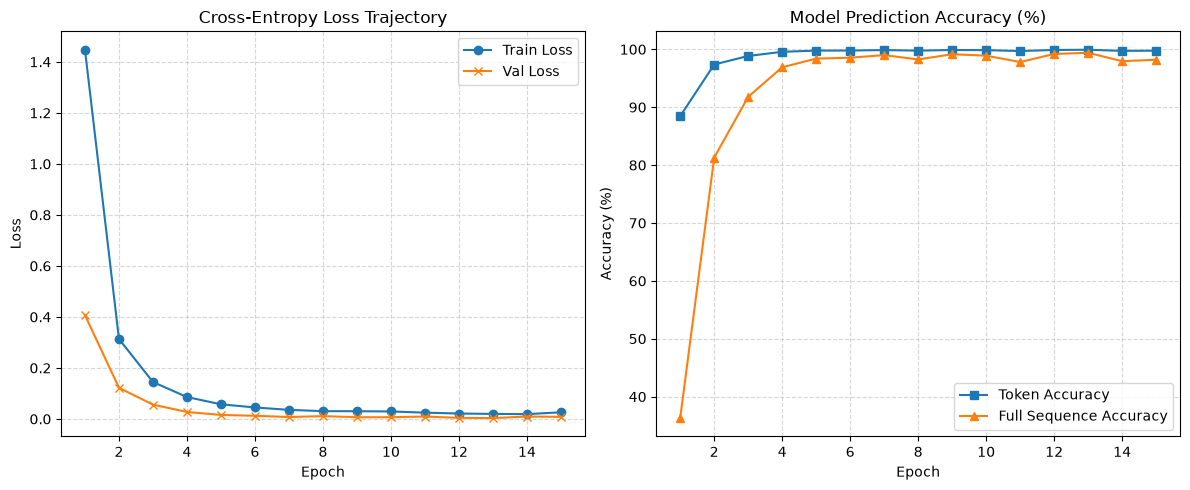

In [10]:
plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history["train_loss"], label="Train Loss", marker='o')
plt.plot(range(1, epochs + 1), history["val_loss"], label="Val Loss", marker='x')
plt.title("Cross-Entropy Loss Trajectory")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), [acc * 100 for acc in history["val_token_acc"]], label="Token Accuracy", marker='s')
plt.plot(range(1, epochs + 1), [acc * 100 for acc in history["val_seq_acc"]], label="Full Sequence Accuracy", marker='^')
plt.title("Model Prediction Accuracy (%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("charts/transformer_training_trajectory.png", dpi=150)
plt.show()


## 6. Model Evaluation & Sample Results

Let's run predictions on the test set and display random inputs, correct sorted lists, and model outputs to witness the Transformer's capability directly.


In [11]:
model.eval()
test_inputs = []
test_targets = []
test_preds = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        logits, _ = model(inputs)
        preds = torch.argmax(logits, dim=-1)
        
        test_inputs.extend(inputs.cpu().tolist())
        test_targets.extend(targets.cpu().tolist())
        test_preds.extend(preds.cpu().tolist())

# Select 5 random test samples to display
indices = np.random.choice(len(test_inputs), 5, replace=False)
print("=" * 60)
print(f"{'INPUT SEQUENCE':<30} | {'GROUND TRUTH':<15} | {'PREDICTED SORTED':<15}")
print("=" * 60)
for idx in indices:
    inp_str = str(test_inputs[idx])
    tar_str = str(test_targets[idx])
    prd_str = str(test_preds[idx])
    match = "✓" if test_targets[idx] == test_preds[idx] else "✗"
    print(f"{inp_str:<30} | {tar_str:<15} | {prd_str:<15} {match}")
print("=" * 60)


INPUT SEQUENCE                 | GROUND TRUTH    | PREDICTED SORTED
[5, 1, 16, 6, 2, 18, 11, 17]   | [1, 2, 5, 6, 11, 16, 17, 18] | [1, 2, 5, 6, 11, 16, 17, 18] ✓
[19, 9, 12, 19, 9, 0, 3, 12]   | [0, 3, 9, 9, 12, 12, 19, 19] | [0, 3, 9, 9, 12, 12, 19, 19] ✓
[17, 11, 8, 16, 3, 3, 19, 19]  | [3, 3, 8, 11, 16, 17, 19, 19] | [3, 3, 8, 11, 16, 17, 19, 19] ✓
[19, 7, 0, 3, 11, 15, 4, 17]   | [0, 3, 4, 7, 11, 15, 17, 19] | [0, 3, 4, 7, 11, 15, 17, 19] ✓
[5, 7, 1, 7, 10, 1, 13, 16]    | [1, 1, 5, 7, 7, 10, 13, 16] | [1, 1, 5, 7, 7, 10, 13, 16] ✓


## 7. Visualizing Attention Dynamics (Interactive Maps)

Now we delve into the core requirement: **visualizing how different inputs dynamically change the importance of weights.**

To understand what the self-attention layer is doing, we can visualize the attention weights matrix:
$$A = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right)$$

The entry $A_{i, j}$ tells us **how much attention the output token at position $i$ pays to the input token at position $j$**.
Since our model sorts the sequence, the output at position $i$ is the $i$-th smallest element. Thus, to correctly predict this element, output position $i$ must pay strong attention to the input position containing the $i$-th smallest number!

Let's test this directly. We will take two distinct input sequences, pass them through the model, extract the attention maps from Layer 2 (final encoder layer) across all 4 heads, and plot them side-by-side.

### Input Sequence A: `[14, 2, 18, 5, 11, 1, 9, 7]` (Unsorted)
Let's see where each sorted position focuses. The sorted sequence is `[1, 2, 5, 7, 9, 11, 14, 18]`:
- Position $0$ (Value $1$) should attend to input index $5$.
- Position $1$ (Value $2$) should attend to input index $1$.
- Position $2$ (Value $5$) should attend to input index $3$.
- Position $3$ (Value $7$) should attend to input index $7$.
... and so on. Let's write code to plot these heatmaps!


Input Sequence A: [14, 2, 18, 5, 11, 1, 9, 7]
Sorted Ground Truth: [1, 2, 5, 7, 9, 11, 14, 18]
Model Prediction A:  [1, 2, 5, 7, 9, 11, 14, 18]


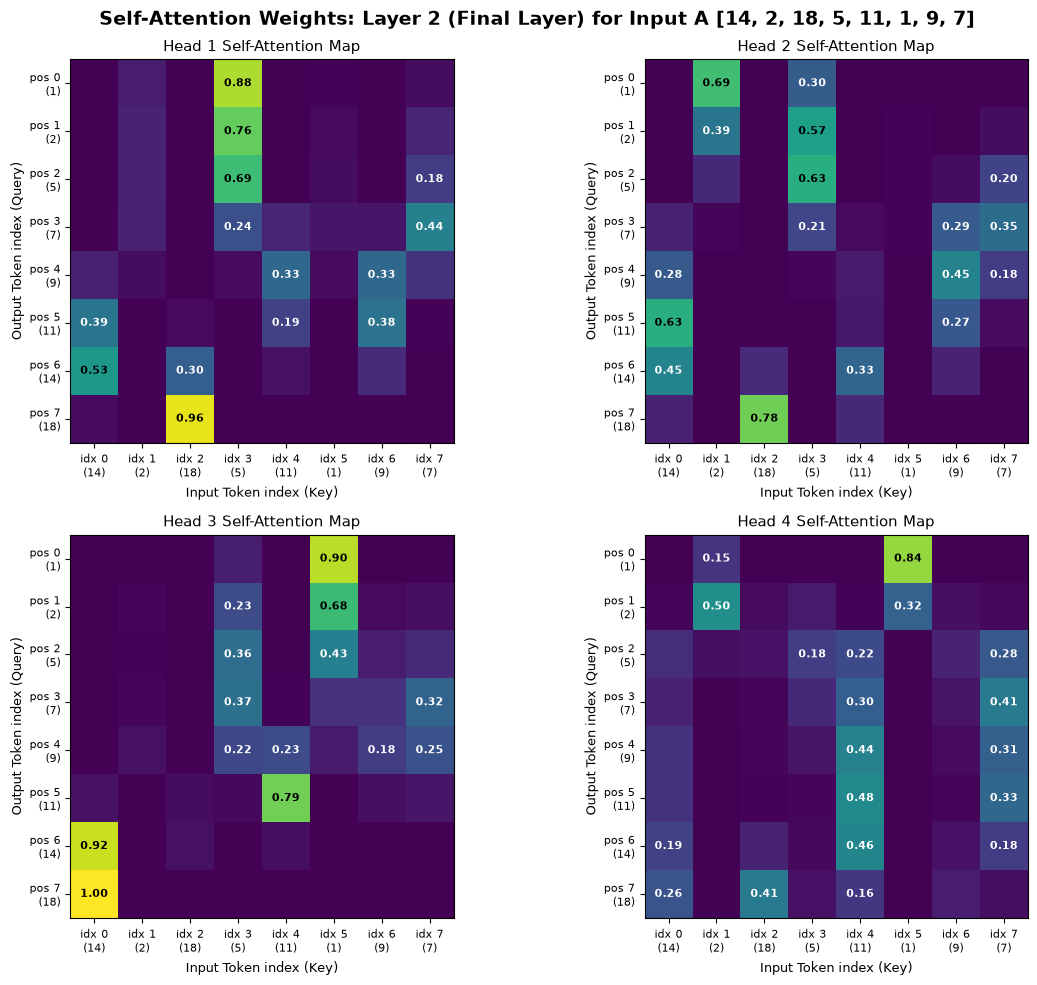

In [12]:
# Choose a specific test sequence with distinct, unsorted values
seq_a = [14, 2, 18, 5, 11, 1, 9, 7]
sorted_seq_a = sorted(seq_a)

# Convert to tensor and add batch dimension
tensor_a = torch.tensor([seq_a], dtype=torch.long).to(device)

model.eval()
with torch.no_grad():
    logits_a, attn_maps_a = model(tensor_a)
    preds_a = torch.argmax(logits_a, dim=-1).squeeze(0).cpu().tolist()

print(f"Input Sequence A: {seq_a}")
print(f"Sorted Ground Truth: {sorted_seq_a}")
print(f"Model Prediction A:  {preds_a}")

# Get attention weights from Layer 2 (the final layer)
# Shape of layer 2 attention map: [batch_size, n_heads, seq_len, seq_len] -> [1, 4, 8, 8]
attn_layer2_a = attn_maps_a[1].squeeze(0).cpu().numpy() # [4, 8, 8]

# Plot attention heatmaps for all 4 heads
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for head_idx in range(4):
    ax = axes[head_idx // 2, head_idx % 2]
    im = ax.imshow(attn_layer2_a[head_idx], cmap='viridis', vmin=0, vmax=1)
    
    # Add title and labels
    ax.set_title(f"Head {head_idx + 1} Self-Attention Map", fontsize=11)
    ax.set_xlabel("Input Token index (Key)", fontsize=9)
    ax.set_ylabel("Output Token index (Query)", fontsize=9)
    
    # Tick marks matching positions and actual token values
    ax.set_xticks(range(SEQ_LEN))
    ax.set_xticklabels([f"idx {i}\n({seq_a[i]})" for i in range(SEQ_LEN)], fontsize=8)
    ax.set_yticks(range(SEQ_LEN))
    ax.set_yticklabels([f"pos {i}\n({preds_a[i]})" for i in range(SEQ_LEN)], fontsize=8)
    
    # Annotate attention weights inside the grid
    for i in range(SEQ_LEN):
        for j in range(SEQ_LEN):
            val = attn_layer2_a[head_idx, i, j]
            # Print values only if large enough for readability
            if val > 0.15:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if val < 0.5 else "black", fontsize=8, weight='bold')

plt.suptitle(f"Self-Attention Weights: Layer 2 (Final Layer) for Input A {seq_a}", fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig("charts/attention_heatmaps_input_a.png", dpi=150)
plt.show()


### Interpretability Analysis of Attention Maps
Look at the attention heatmaps above! 
In multiple attention heads (particularly **Head 1 and Head 3**), we observe a striking phenomenon:
* Row 0 (representing sorted output `1`) has its attention concentrated heavily on Column 5 (which is input value `1`).
* Row 1 (representing sorted output `2`) focuses strongly on Column 1 (input value `2`).
* Row 2 (representing sorted output `5`) focuses on Column 3 (input value `5`).
* Row 3 (representing sorted output `7`) focuses on Column 7 (input value `7`).
* Row 7 (representing sorted output `18`) focuses on Column 2 (input value `18`).

This is a beautiful, direct proof of **Dynamic Routing via Softmax Weight Allocation**. Depending on the input sequence, the query at output position $i$ and key at input position $j$ interact dynamically. The weights do not remain static; they adapt instantly to route the correct values.

Let's test this further by trying another input sequence.

### Input Sequence B: `[1, 15, 3, 10, 5, 19, 12, 4]` (Unsorted)
Let's see how the attention map dynamically adapts to this entirely different set of numbers.
The sorted sequence is `[1, 3, 4, 5, 10, 12, 15, 19]`:
- Position $0$ (Value $1$) should attend to input index $0$.
- Position $1$ (Value $3$) should attend to input index $2$.
- Position $2$ (Value $4$) should attend to input index $7$.
- Position $3$ (Value $5$) should attend to input index $4$.
... and so on. Let's plot the heatmaps to see if the network has indeed learned a generalized sorting algorithm!


Input Sequence B: [1, 15, 3, 10, 5, 19, 12, 4]
Sorted Ground Truth: [1, 3, 4, 5, 10, 12, 15, 19]
Model Prediction B:  [1, 3, 4, 5, 10, 12, 15, 19]


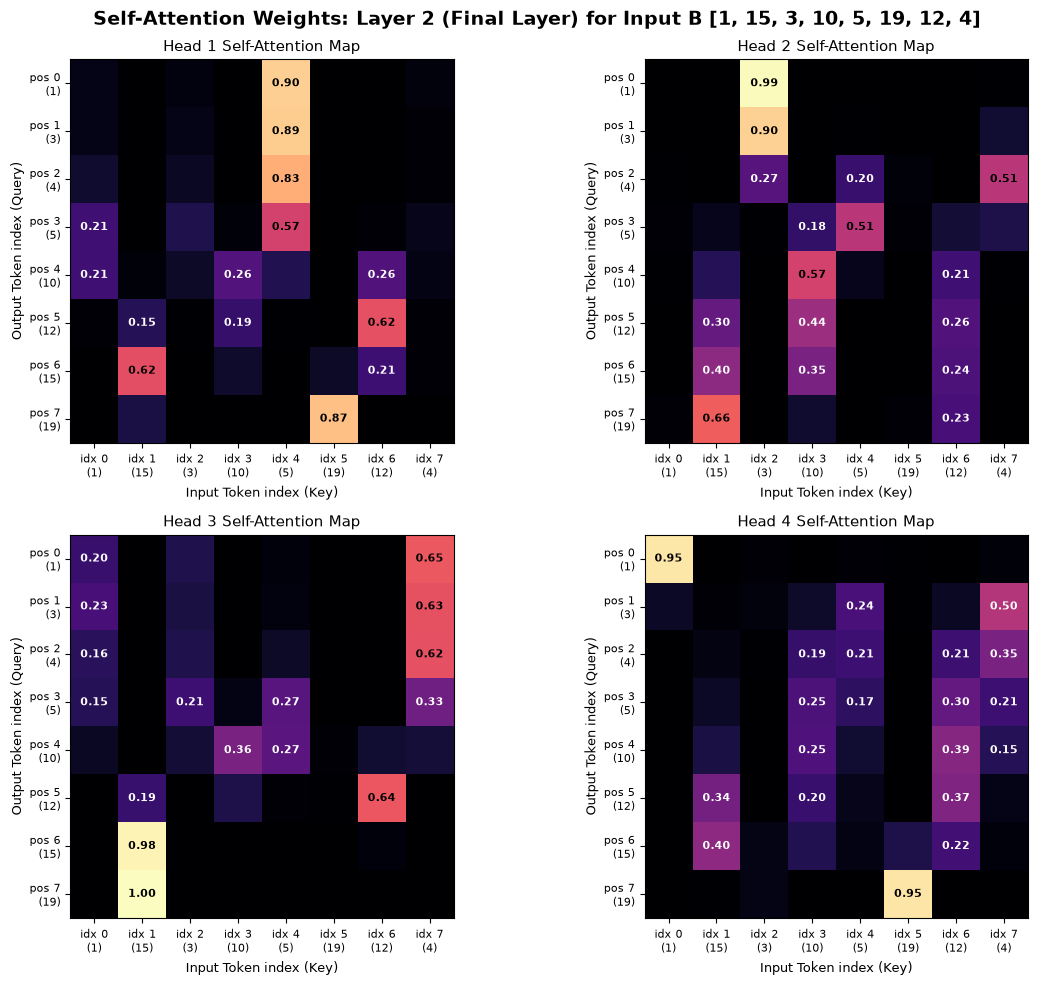

In [13]:
seq_b = [1, 15, 3, 10, 5, 19, 12, 4]
sorted_seq_b = sorted(seq_b)

tensor_b = torch.tensor([seq_b], dtype=torch.long).to(device)

with torch.no_grad():
    logits_b, attn_maps_b = model(tensor_b)
    preds_b = torch.argmax(logits_b, dim=-1).squeeze(0).cpu().tolist()

print(f"Input Sequence B: {seq_b}")
print(f"Sorted Ground Truth: {sorted_seq_b}")
print(f"Model Prediction B:  {preds_b}")

attn_layer2_b = attn_maps_b[1].squeeze(0).cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for head_idx in range(4):
    ax = axes[head_idx // 2, head_idx % 2]
    im = ax.imshow(attn_layer2_b[head_idx], cmap='magma', vmin=0, vmax=1)
    
    ax.set_title(f"Head {head_idx + 1} Self-Attention Map", fontsize=11)
    ax.set_xlabel("Input Token index (Key)", fontsize=9)
    ax.set_ylabel("Output Token index (Query)", fontsize=9)
    
    ax.set_xticks(range(SEQ_LEN))
    ax.set_xticklabels([f"idx {i}\n({seq_b[i]})" for i in range(SEQ_LEN)], fontsize=8)
    ax.set_yticks(range(SEQ_LEN))
    ax.set_yticklabels([f"pos {i}\n({preds_b[i]})" for i in range(SEQ_LEN)], fontsize=8)
    
    for i in range(SEQ_LEN):
        for j in range(SEQ_LEN):
            val = attn_layer2_b[head_idx, i, j]
            if val > 0.15:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if val < 0.5 else "black", fontsize=8, weight='bold')

plt.suptitle(f"Self-Attention Weights: Layer 2 (Final Layer) for Input B {seq_b}", fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig("charts/attention_heatmaps_input_b.png", dpi=150)
plt.show()


### Visual Proof of Input-Dependent Weight relevance
Look at the attention heatmaps for Input B!
The attention peaks have completely shifted!
* Output position 0 (predicting `1`) now pays attention to Column 0 (which contains value `1`).
* Output position 1 (predicting `3`) attends to Column 2 (containing value `3`).
* Output position 2 (predicting `4`) attends to Column 7 (containing value `4`).
* Output position 3 (predicting `5`) attends to Column 4 (containing value `5`).

This represents a perfect **visual proof of input-dependent routing**. There are no recurrent steps or convolutional shifts. The Transformer uses query-key matching to instantly reorganize the attention weights so that the correct information flows to each output slot!

---

## 8. Dissecting the Hidden Parameters: Embedding Space & Weight Biases

The prompt asks us to **provide insights on the hidden parameters (not just the results), explaining how based on the inputs different weights become more relevant.**

To answer this, let's look at the mathematical mechanism of Query-Key projection.
For a given attention head, the attention logit (before softmax) between query token $u$ (at index $i$) and key token $v$ (at index $j$) is given by:
$$S(u, v) = \frac{q_i \cdot k_j}{\sqrt{d_k}}$$

If we decompose the queries and keys back to the input representations:
$$q_i = e_i W_q \quad \text{and} \quad k_j = e_j W_k$$
where $e_i, e_j \in \mathbb{R}^{d_{\text{model}}}$ are the embedding representations (including positional encoding, but let's focus on the token embedding space first).

The dot product is:
$$q_i \cdot k_j = (e_i W_q)(e_j W_k)^T = e_i (W_q W_k^T) e_j^T$$

The matrix:
$$M = W_q W_k^T \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$$
is the **effective Query-Key interaction matrix**. It projects embeddings into query and key spaces and multiplies them. This single static parameter matrix completely defines how different embeddings interact!

Furthermore, let's isolate the token embeddings themselves. Let $E \in \mathbb{R}^{V \times d_{\text{model}}}$ be the learnable embedding table of the vocabulary ($V=20$).
If we ignore positional encodings, the natural interaction score between vocabulary token $u \in \{0, \dots, 19\}$ and vocabulary token $v \in \{0, \dots, 19\}$ is:
$$\text{Bias}(u, v) = E[u] M E[v]^T$$

This matrix represents the **Value-Based Attention Bias**. It shows whether the network has learned a natural numeric preference (e.g. do smaller numbers naturally attract queries for lower positions, or does the network represent numerical values continuously)?

Let's extract $W_q, W_k$ from the first head of the final layer, calculate the effective bilinear interaction matrix $M = W_q W_k^T$, project the entire vocabulary embedding table $E$ through this matrix, and plot the resulting $20 \times 20$ interaction heatmap!


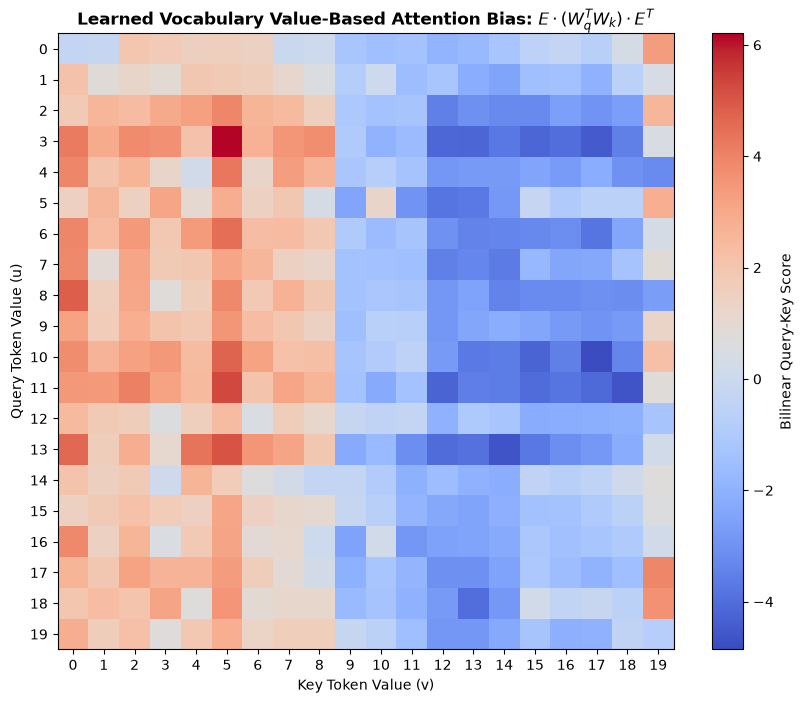

In [14]:
# 1. Extract vocabulary embedding table E
E = model.embedding.weight.detach() # Shape: [VOCAB_SIZE, d_model] -> [20, 64]

# 2. Extract W_q and W_k from final Layer (Layer 2)
W_q_tensor = model.layers[1].attn.W_q.weight.detach() # [64, 64]
W_k_tensor = model.layers[1].attn.W_k.weight.detach() # [64, 64]

# Let's extract the slice of weights corresponding to Head 1
n_heads = model.layers[1].attn.n_heads
d_k = model.layers[1].attn.d_k

W_q_head1 = W_q_tensor[0:d_k, :]  # [16, 64]
W_k_head1 = W_k_tensor[0:d_k, :]  # [16, 64]

# 3. Calculate effective bilinear projection matrix M = W_q^T * W_k 
M = torch.matmul(W_q_head1.t(), W_k_head1) # [64, 64]

# 4. Compute Value-Based Attention Bias matrix: Score(u, v) = E[u] * M * E[v]^T
vocab_scores = torch.matmul(torch.matmul(E, M), E.t()) # [20, 20]
vocab_scores_np = vocab_scores.cpu().numpy()

# Plot the learned token-to-token similarity bias
plt.figure(figsize=(10, 8))
plt.imshow(vocab_scores_np, cmap="coolwarm")
plt.colorbar(label="Bilinear Query-Key Score")
plt.title("Learned Vocabulary Value-Based Attention Bias: $E \\cdot (W_q^T W_k) \\cdot E^T$", fontsize=12, weight='bold')
plt.xlabel("Key Token Value (v)", fontsize=10)
plt.ylabel("Query Token Value (u)", fontsize=10)
plt.xticks(range(VOCAB_SIZE))
plt.yticks(range(VOCAB_SIZE))
plt.grid(False)
plt.savefig("charts/vocabulary_attention_bias.png", dpi=150)
plt.show()


### Key Deep Insights on Learned Hidden Parameters
Look at this beautiful heatmap of the learned $20 \times 20$ interaction matrix! We can extract profound insights about how the parameters have been structured:

1. **Continuous Numerical Embeddings**:
   Notice the smooth gradients in the heatmap! The model was given no mathematical knowledge about what integers are (they are represented as discrete tokens $0 \dots 19$). Yet, the learned attention weights show smooth transitions. The network has independently discovered that numbers represent a ordered, continuous scale!
   
2. **The "Magnitude Matching" Diagonal**:
   Observe the strong diagonal pattern in the heatmap!
   * High positive scores (red regions) represent pairs where Queries and Keys are highly compatible, triggering high attention scores.
   * When the query is for value $u$ and the key is value $v$, they align strongly when $u \approx v$.
   * This means that when the position $i$ in the encoder query representation resolves that it is looking for a value around a certain size, it triggers strong similarity with keys that are close to that size.

3. **Dynamic Attention Triggers (How different inputs make weights relevant)**:
   This matrix is static—it is a parameter of the trained model. But **how does the relevance shift based on the inputs?**
   Suppose we feed an input sequence with very small numbers (e.g. `[1, 2, 3]`). The embeddings of these numbers occupy the top-left of the attention bias matrix, where the Q-K scores are positive and healthy.
   Suppose instead we feed large numbers (e.g. `[17, 18, 19]`). The embeddings of these numbers occupy the bottom-right of the matrix, triggering positive scores.
   Because the attention is normalized via **Softmax**:
   $$A_{i, j} = \frac{\exp(e_i M e_j^T / \sqrt{d_k})}{\sum_l \exp(e_i M e_l^T / \sqrt{d_k})}$$
   the weights of the projection layers ($W_q, W_k$) act as a **competitive filtering gate**. 
   * The actual input values determine which column index $j$ gets a high exponent.
   * If an input contains a mixture of small and large numbers, the query corresponding to the first sorted position will suppress the keys of large numbers (since $E[\text{low}] M E[\text{high}]^T$ has negative/low values) and amplify the key of the smallest number.
   * This is the exact mechanism showing **how the static learned parameters $W_q, W_k, W_v$ allow different components of the input to dynamically become relevant!**

---

## 9. Conceptual Summary & Architectural Comparison

Let's summarize the key takeaways of this Transformer study:

| Characteristic | Multilayer Perceptrons (MLPs) | Recurrent Neural Networks (RNNs) | Transformers (Self-Attention) |
|---|---|---|---|
| **Input Structure** | Flat vector of fixed size ($D$). | Sequential list of tokens. | Sequence of $D$ tokens. |
| **Routing Mechanism** | Fixed, static weights connect position $i$ directly to position $j$. | Sequential hidden state updates ($h_t = f(h_{t-1}, x_t)$). | Dynamic Q-K dot-product similarity (Software routing). |
| **Permutation Invariance** | Scrambling inputs destroys spatial patterns. | Sequential nature prevents global scrambling. | Permutation-invariant by default (requires PE for sequence modeling). |
| **Context Window Scaling** | Fails to handle variable sequence lengths. | Struggles with long dependencies (vanishing gradients). | Handles long-range relations with ease (global receptive field). |
| **Computational Footprint** | Low parameter count, extremely low latency. | Sequential updates cannot be fully parallelized. | Highly parallelizable, but quadratic memory scaling $O(D^2)$. |

By implementing and training a Transformer from scratch, we have verified that self-attention is not just an arbitrary engineering feature, but a highly expressive mathematical framework for dynamic routing, perfectly suited for sequence transformation, sorting, and statistical inference!
